# Overhead Analysis (End-of-Slot Control)

This notebook summarizes end-of-slot overhead for **GDBT**, **IL-no-guard**, and **IL-guard** using the dedicated `results/overhead` logs.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_project_root() -> Path:
    cur = Path('.').resolve()
    for _ in range(6):
        if (cur / 'results' / 'overhead').exists():
            return cur
        if (cur / 'results').exists() and (cur / 'src').exists():
            return cur
        cur = cur.parent
    return Path('.').resolve()


PROJECT_ROOT = _find_project_root()
ROOT = PROJECT_ROOT / 'results' / 'overhead'
FIG_DIR = PROJECT_ROOT / 'results' / 'figures'
TAB_DIR = PROJECT_ROOT / 'results' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'wikipedia_september_2007': ROOT / 'wikipedia_september_2007',
    'wiki2018': ROOT / 'wiki2018',
}

MODEL_PATTERNS = {
    'GBDT': 'summary_gdbt_A2_overhead_*.json',
    'IL-no-guard': 'summary_ilnse_A2_guard_no_guard_nb_overhead_*.json',
    'IL-guard': 'summary_ilnse_A2_guard_full_nb_overhead_*.json',
}


In [2]:
def _pick_summary(dataset_dir: Path, pattern: str) -> Path:
    # pick the latest by filename sort (run_id prefix)
    paths = sorted(dataset_dir.glob(f"*{pattern}"))
    paths = [p for p in paths if '_all_sizes' not in p.name]
    if not paths:
        raise FileNotFoundError(f"No summary files for pattern={pattern} in {dataset_dir}")
    return paths[-1]


def _summary_to_jsonl_path(summary_path: Path) -> Path:
    name = summary_path.name.replace('_summary_', '_')
    return summary_path.with_name(name.replace('.json', '.jsonl'))


def _load_slot_rows(jsonl_path: Path):
    rows = []
    with jsonl_path.open() as f:
        for line in f:
            if not line.strip():
                continue
            d = json.loads(line)
            if d.get('phase') != 'cache':
                continue
            # ensure time_slot_s exists
            if 'time_slot_s' not in d:
                d['time_slot_s'] = sum(
                    float(d.get(k, 0.0))
                    for k in ['time_feat_s', 'time_score_s', 'time_guard_s', 'time_select_s', 'time_update_s']
                )
            rows.append(d)
    return rows


def _safe_mean(arr):
    return float(np.mean(arr)) if len(arr) else None


def _safe_pct(arr, q):
    return float(np.percentile(arr, q)) if len(arr) else None


In [3]:
records = []
slot_data = {}

for dataset, ds_dir in DATASETS.items():
    slot_data[dataset] = {}
    for model_label, pattern in MODEL_PATTERNS.items():
        summary_path = _pick_summary(ds_dir, pattern)
        summary = json.loads(summary_path.read_text())
        jsonl_path = _summary_to_jsonl_path(summary_path)
        rows = _load_slot_rows(jsonl_path)
        slot_data[dataset][model_label] = rows

        times = np.array([r.get('time_slot_s', 0.0) for r in rows], dtype=float)
        feat = np.array([r.get('time_feat_s', 0.0) for r in rows], dtype=float)
        score = np.array([r.get('time_score_s', 0.0) for r in rows], dtype=float)
        guard = np.array([r.get('time_guard_s', 0.0) for r in rows], dtype=float)
        sel = np.array([r.get('time_select_s', 0.0) for r in rows], dtype=float)
        upd = np.array([r.get('time_update_s', 0.0) for r in rows], dtype=float)
        miss_cand = np.array([r.get('miss_candidates', 0) for r in rows], dtype=float)

        score_per_cand = np.array([
            (s / c) if c > 0 else 0.0
            for s, c in zip(score, miss_cand)
        ])

        records.append({
            'dataset': dataset,
            'model': model_label,
            'cache_size_objects': summary.get('cache_size_objects'),
            'slots': len(rows),
            'avg_time_slot_s': _safe_mean(times),
            'p95_time_slot_s': _safe_pct(times, 95),
            'p99_time_slot_s': _safe_pct(times, 99),
            'max_time_slot_s': float(np.max(times)) if len(times) else None,
            'avg_time_feat_s': _safe_mean(feat),
            'avg_time_score_s': _safe_mean(score),
            'avg_time_guard_s': _safe_mean(guard),
            'avg_time_select_s': _safe_mean(sel),
            'avg_time_update_s': _safe_mean(upd),
            'avg_score_time_per_cand_us': _safe_mean(score_per_cand) * 1e6,
            'rss_max_mb': summary.get('rss_max_mb'),
            'max_feature_bytes': summary.get('max_feature_bytes'),
            'num_features': summary.get('num_features'),
        })

summary_df = pd.DataFrame(records)
summary_df


,dataset,model,cache_size_objects,slots,avg_time_slot_s,p95_time_slot_s,p99_time_slot_s,max_time_slot_s,avg_time_feat_s,avg_time_score_s,avg_time_guard_s,avg_time_select_s,avg_time_update_s,avg_score_time_per_cand_us,rss_max_mb,max_feature_bytes,num_features
0,wikipedia_september_2007,GBDT,12221,80,25.960157,60.663831,77.749144,98.256297,5.925070,17.846012,0.000000,0.000000,2.189075,443.656454,2533468.0,0,10
1,wikipedia_september_2007,IL-no-guard,12221,80,4.154379,11.426951,26.990687,41.728873,2.574212,0.590705,0.158018,0.005657,0.825787,17.188854,2702228.0,8000000,10
2,wikipedia_september_2007,IL-guard,12221,80,4.478425,12.462630,37.702715,48.954138,2.893238,0.585732,0.163163,0.006376,0.829915,17.170927,2683808.0,8000000,10
3,wiki2018,GBDT,16123,90,26.059439,71.889231,109.781649,112.762021,4.878081,18.190767,0.000000,0.000000,2.990591,306.807985,3263120.0,0,10
4,wiki2018,IL-no-guard,16123,90,5.400072,13.747749,26.005680,35.051881,2.915041,0.887564,0.265141,0.020831,1.311496,17.592008,3891260.0,8000000,10
5,wiki2018,IL-guard,16123,90,5.188154,14.661380,17.976533,20.126689,2.731545,0.879597,0.258011,0.007950,1.311051,17.588137,3848920.0,8000000,10


In [4]:
# Save overhead summary tables (full + compact)
summary_df = summary_df.sort_values(['dataset', 'model'])

# Fix RSS unit if needed (macOS ru_maxrss is bytes -> logged as KB)
summary_df['rss_peak_mb'] = summary_df['rss_max_mb']
summary_df.loc[summary_df['rss_peak_mb'] > 1e4, 'rss_peak_mb'] = (
    summary_df.loc[summary_df['rss_peak_mb'] > 1e4, 'rss_peak_mb'] / 1024.0
)

summary_df.to_csv(TAB_DIR / 'overhead_summary.csv', index=False)
summary_df.to_latex(TAB_DIR / 'overhead_summary.tex', index=False, float_format='%.6f')

compact_cols = [
    'dataset', 'model', 'cache_size_objects',
    'avg_time_slot_s', 'p95_time_slot_s', 'p99_time_slot_s',
    'avg_score_time_per_cand_us', 'rss_peak_mb'
]
compact_df = summary_df[compact_cols].copy()
compact_df.to_csv(TAB_DIR / 'overhead_summary_compact.csv', index=False)
compact_df.to_latex(TAB_DIR / 'overhead_summary_compact.tex', index=False, float_format='%.6f')
compact_df


/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_50421/943105770.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  summary_df.to_latex(TAB_DIR / 'overhead_summary.tex', index=False, float_format='%.6f')
/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_50421/943105770.py:20: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  compact_df.to_latex(TAB_DIR / 'overhead_summary_compact.tex', index=False, float_format='%.6f')


,dataset,model,cache_size_objects,avg_time_slot_s,p95_time_slot_s,p99_time_slot_s,avg_score_time_per_cand_us,rss_peak_mb
3,wiki2018,GBDT,16123,26.059439,71.889231,109.781649,306.807985,3186.640625
5,wiki2018,IL-guard,16123,5.188154,14.661380,17.976533,17.588137,3758.710938
4,wiki2018,IL-no-guard,16123,5.400072,13.747749,26.005680,17.592008,3800.058594
0,wikipedia_september_2007,GBDT,12221,25.960157,60.663831,77.749144,443.656454,2474.089844
2,wikipedia_september_2007,IL-guard,12221,4.478425,12.462630,37.702715,17.170927,2620.906250
1,wikipedia_september_2007,IL-no-guard,12221,4.154379,11.426951,26.990687,17.188854,2638.894531


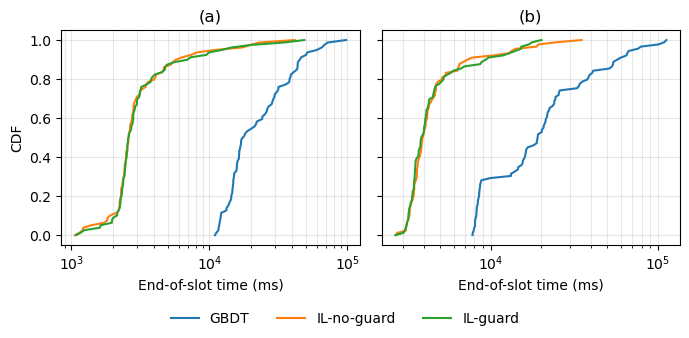

In [5]:
# CDF plots of end-of-slot time (log-x) with shared legend
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.4), sharey=True)
legend_handles = None
legend_labels = None

pretty_titles = {
    'wikipedia_september_2007': 'Wikipedia Sep-2007',
    'wiki2018': 'Wiki2018',
}

for idx, (ax, (dataset, data_by_model)) in enumerate(zip(axes, slot_data.items())):
    alias_keys = {
        'GBDT': ['GBDT'],
        'IL-no-guard': ['IL-no-guard', 'IL_no_guard'],
        'IL-guard': ['IL-guard', 'IL_guard', 'IL_Guard'],
    }
    for model_label in ['GBDT', 'IL-no-guard', 'IL-guard']:
        rows = None
        for key in alias_keys[model_label]:
            if key in data_by_model:
                rows = data_by_model[key]
                break
        if rows is None:
            continue
        times = np.array([r.get('time_slot_s', 0.0) for r in rows], dtype=float)
        if len(times) == 0:
            continue
        times_ms = np.clip(times * 1e3, 1e-3, None)
        xs = np.sort(times_ms)
        ys = np.linspace(0, 1, len(xs), endpoint=True)
        ax.plot(xs, ys, label=model_label)

    # ax.set_title(dataset)
    ax.set_title(f"({chr(97 + idx)})")
    ax.set_xlabel('End-of-slot time (ms)')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3, which='both')

axes[0].set_ylabel('CDF')

# Shared legend below
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(FIG_DIR / 'overhead_cdf_panel.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'overhead_cdf_panel.pdf', bbox_inches='tight')
plt.show()
